In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emnist' dataset.
Path to dataset files: /kaggle/input/emnist


In [ ]:
import os
for root, dirs, files in os.walk(path):
  for file in files:
    print(os.path.join(root, file))

/kaggle/input/emnist/emnist-letters-mapping.txt
/kaggle/input/emnist/emnist-letters-test.csv
/kaggle/input/emnist/emnist-mnist-mapping.txt
/kaggle/input/emnist/emnist-digits-train.csv
/kaggle/input/emnist/emnist-bymerge-mapping.txt
/kaggle/input/emnist/emnist-balanced-train.csv
/kaggle/input/emnist/emnist-digits-test.csv
/kaggle/input/emnist/emnist-balanced-test.csv
/kaggle/input/emnist/emnist-mnist-test.csv
/kaggle/input/emnist/emnist-letters-train.csv
/kaggle/input/emnist/emnist-byclass-train.csv
/kaggle/input/emnist/emnist-bymerge-test.csv
/kaggle/input/emnist/emnist-balanced-mapping.txt
/kaggle/input/emnist/emnist-mnist-train.csv
/kaggle/input/emnist/emnist-digits-mapping.txt
/kaggle/input/emnist/emnist-bymerge-train.csv
/kaggle/input/emnist/emnist-byclass-test.csv
/kaggle/input/emnist/emnist-byclass-mapping.txt
/kaggle/input/emnist/emnist_source_files/emnist-digits-test-labels-idx1-ubyte
/kaggle/input/emnist/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte
/kaggle/input/

In [ ]:
import pandas as pd
train=pd.read_csv(path+'/emnist-letters-train.csv')
test=pd.read_csv(path+'/emnist-letters-test.csv')

In [ ]:
y_train=train.iloc[:,0].values
x_train=train.iloc[:,1:].values
y_test=test.iloc[:,0].values
x_test=test.iloc[:,1:].values
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(88799, 784)
(14799, 784)
(88799,)
(14799,)


In [ ]:
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


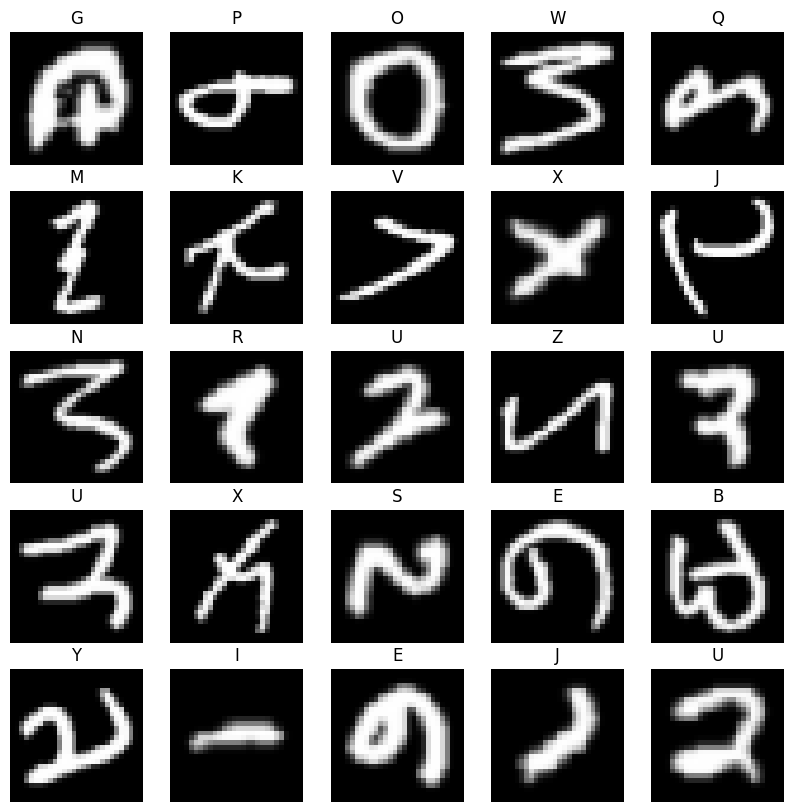

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]-1]) # y_train already contains integer labels
    plt.axis('off')
plt.show()

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

In [ ]:
y_train=to_categorical(y_train-1,num_classes=26)
y_test=to_categorical(y_test-1,num_classes=26)

In [ ]:
model = Sequential()


model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1))) # Adjusted input_shape for EMNIST
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(26, activation='softmax')) # Adjusted output Dense layer for EMNIST classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,370 (1.67 MB)

 Trainable params: 437,370 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.7497 - loss: 0.8141 - val_accuracy: 0.9172 - val_loss: 0.2520
Epoch 2/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8897 - loss: 0.3499 - val_accuracy: 0.9279 - val_loss: 0.2252
Epoch 3/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9082 - loss: 0.2893 - val_accuracy: 0.9365 - val_loss: 0.1975
Epoch 4/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9172 - loss: 0.2597 - val_accuracy: 0.9382 - val_loss: 0.1922
Epoch 5/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9214 - loss: 0.2418 - val_accuracy: 0.9413 - val_loss: 0.1950
Epoch 6/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9253 - loss: 0.2248 - val_accuracy: 0.9441 - val_loss: 0.1780
Epoch 7/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9296 - loss: 0.2169 - val_accuracy: 0.9417 - val_loss: 0.1831
Epoch 8/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9317 - loss: 0

In [ ]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss",test_loss)
print("Test Accuracy",test_accuracy)


463/463 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9313 - loss: 0.2022
Test Loss 0.20224682986736298
Test Accuracy 0.9312791228294373


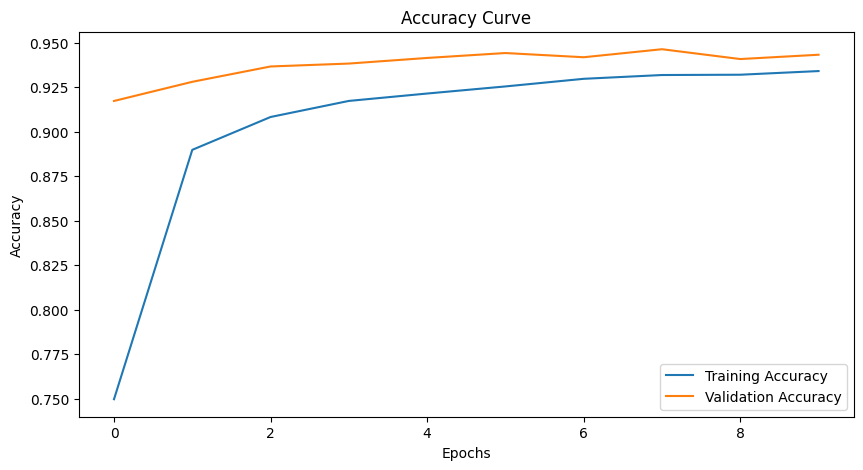

In [ ]:
#Accuracy curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

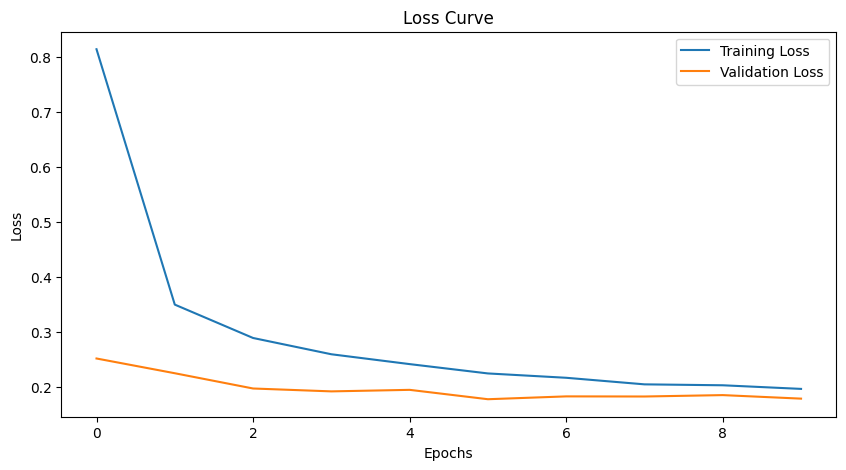

In [ ]:
#loss curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
Actual class: A


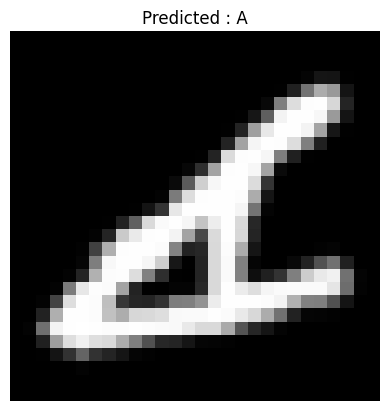

In [ ]:
sample=x_test[0]
prediction=model.predict(sample.reshape(1,28,28,1)) # Reshape for EMNIST input
actual_class=np.argmax(y_test[0])
predicted_class=np.argmax(prediction)
actual_class=np.argmax(y_test[0])
plt.imshow(sample.squeeze(),cmap='gray') # Show grayscale, squeeze for correct display
plt.title(f'Predicted : {class_names[predicted_class]}')
print(f'Actual class: {class_names[actual_class]}')
plt.axis('off')
plt.show()

Saving Q.png to Q.png


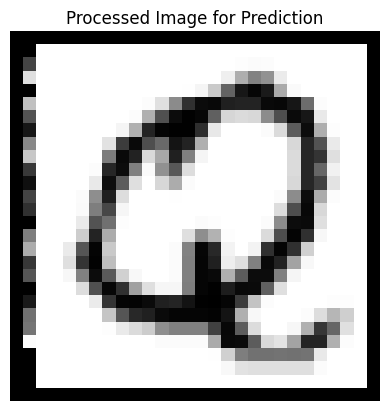

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted : Q
Confidence score: 57.62999 %

Full prediction probabilities:
  A: 5.60%
  B: 6.64%
  C: 0.08%
  D: 10.38%
  E: 0.43%
  F: 0.27%
  G: 8.81%
  H: 0.15%
  I: 0.01%
  J: 0.08%
  K: 0.02%
  L: 0.16%
  M: 0.13%
  N: 0.18%
  O: 2.73%
  P: 4.05%
  Q: 57.63%
  R: 0.65%
  S: 0.12%
  T: 0.01%
  U: 0.16%
  V: 0.01%
  W: 0.89%
  X: 0.11%
  Y: 0.42%
  Z: 0.27%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2

uploaded=files.upload()
file_path=list(uploaded.keys())[0]
img=cv2.imread(file_path, cv2.IMREAD_GRAYSCALE) # Read as grayscale
img=cv2.resize(img,(28,28))
img=cv2.rotate(img,cv2.ROTATE_90_CLOCKWISE)
img=cv2.flip(img,1)

# Invert image (EMNIST usually has white text on black background)
img=255-img
# Normalize
img=img.astype('float32')/255.0

# Reshape for model input (add batch and channel dimensions)
img_for_prediction=img.reshape(1,28,28,1)

# Display the image after all preprocessing (what the model 'sees')
plt.imshow(img, cmap='gray') # Show grayscale
plt.title('Processed Image for Prediction')
plt.axis('off')
plt.show()

# Predict
prediction=model.predict(img_for_prediction)
predicted_class=np.argmax(prediction)

print('Predicted :',class_names[predicted_class])

# Print confidence score for the predicted class
print('Confidence score:',np.max(prediction)*100,'%')

# Print full prediction probabilities
print('\nFull prediction probabilities:')
for i, prob in enumerate(prediction[0]):
    print(f'  {class_names[i]}: {prob*100:.2f}%')


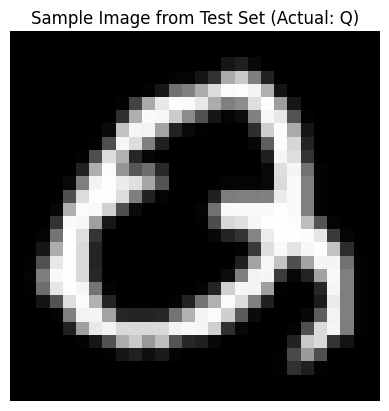

A sample image 'sample_test_image.png' has been saved. You can download it and then use it in the upload cell.


In [ ]:
random_index = np.random.randint(0, len(x_test))
example_image = x_test[random_index].reshape(28, 28)

plt.imshow(example_image, cmap='gray')
plt.title(f'Sample Image from Test Set (Actual: {class_names[np.argmax(y_test[random_index])]})')
plt.axis('off')
plt.show()

# Save the image so the user can download it
plt.imsave('sample_test_image.png', example_image, cmap='gray')
print("A sample image 'sample_test_image.png' has been saved. You can download it and then use it in the upload cell.")
